# 04 — Interpretability Analysis

Sections A–C interpret the **selected final model** (`treatment1`: RandomForest,
CONFIG\_A team-only features, training window 1998–2014).
Sections D–E add cross-model analyses comparing `treatment1` vs `treatment2`.

| Section | Method | Scope |
|---------|--------|-------|
| **A** | SHAP (TreeExplainer) | Global feature importance, direction (beeswarm), local waterfall |
| **B** | LIME (LimeTabularExplainer) | Local linear approximations for individual matches |
| **C** | Structural analyses | Defending-champion effect · Elo vs squad divergence · Geographic bias |
| **D** | Edge-case analysis | Upset explanation: t1 vs t2 confidence comparison, SHAP deep dive |
| **E** | Stage-wise analysis | Group stage vs knockout: does player quality matter more under pressure? |

In [33]:
import warnings

warnings.filterwarnings("ignore")

import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import label_binarize
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

import lightgbm as lgb
import xgboost as xgb
import shap

try:
    import lime
    import lime.lime_tabular

    HAS_LIME = True
except ImportError:
    print("LIME not installed. Run: pip install lime")
    HAS_LIME = False

plt.style.use("seaborn-v0_8-whitegrid")
SEED = 42

BASE = Path("../../../../")
DB_PATH = BASE / "data/raw/worldcup/data-sqlite/worldcup.db"
DATA = Path("./data")
CLASS_LABELS = ["fav_loses", "draw", "fav_wins"]
HOLDOUT_YEARS = [2018, 2022]

assert DB_PATH.is_file(), "DB not found"
assert (DATA / "features_team.parquet").is_file(), "Run 01 first"
assert (DATA / "features_player_squad.parquet").is_file(), "Run 02 first"
print("Inputs found.")

Inputs found.


In [34]:
# ── Re-build df_fav (same logic as 03_model_training B1–B2) ─────────────
# We re-run the data preparation here so this notebook is self-contained.
# (Copy of the minimal pipeline from 03 — keep in sync if you modify feature logic.)

feat_team = pd.read_parquet(DATA / "features_team.parquet")
feat_ps = pd.read_parquet(DATA / "features_player_squad.parquet")

con = sqlite3.connect(DB_PATH)


def _sql(q):
    return pd.read_sql_query(q, con)


matches = _sql("SELECT * FROM matches")
tournaments = _sql("SELECT tournament_id, tournament_name, year FROM tournaments")
teams_db = _sql("SELECT team_id, confederation_id, team_name FROM teams")
con.close()

matches["match_dt"] = pd.to_datetime(
    matches["match_date"], unit="D", origin="unix", errors="coerce"
)
men_ids = tournaments.loc[
    ~tournaments["tournament_name"].str.contains("Women", case=False, na=False),
    "tournament_id",
].unique()
matches = matches[matches["tournament_id"].isin(men_ids)].copy()
matches = matches.merge(
    tournaments[["tournament_id", "year"]], on="tournament_id", how="left"
)

# Schedule
sched = matches[
    ["match_id", "tournament_id", "home_team_id", "away_team_id", "match_dt", "year"]
].copy()
long = pd.concat(
    [
        sched.rename(columns={"home_team_id": "team_id", "away_team_id": "opp_id"}),
        sched.rename(columns={"away_team_id": "team_id", "home_team_id": "opp_id"}),
    ],
    ignore_index=True,
).sort_values(["tournament_id", "team_id", "match_dt", "match_id"])
long["prev_dt"] = long.groupby(["tournament_id", "team_id"])["match_dt"].shift(1)
long["rest_days"] = (long["match_dt"] - long["prev_dt"]).dt.days
rest_home = long.rename(
    columns={"team_id": "home_team_id", "rest_days": "home_rest_days"}
)
rest_away = long.rename(
    columns={"team_id": "away_team_id", "rest_days": "away_rest_days"}
)
matches = matches.merge(
    rest_home[["match_id", "home_team_id", "home_rest_days"]],
    on=["match_id", "home_team_id"],
    how="left",
)
matches = matches.merge(
    rest_away[["match_id", "away_team_id", "away_rest_days"]],
    on=["match_id", "away_team_id"],
    how="left",
)

# Join team features
ft_home = feat_team.add_prefix("home_").rename(
    columns={"home_tournament_id": "tournament_id", "home_team_id": "home_team_id"}
)
ft_away = feat_team.add_prefix("away_").rename(
    columns={"away_tournament_id": "tournament_id", "away_team_id": "away_team_id"}
)
df_all = matches.merge(ft_home, on=["tournament_id", "home_team_id"], how="left")
df_all = df_all.merge(ft_away, on=["tournament_id", "away_team_id"], how="left")
df_all["feat_same_confederation"] = (
    df_all["home_confederation_id"] == df_all["away_confederation_id"]
).astype(int)

# Fav/und framing
home_elo = df_all["home_elo_rating"].fillna(0)
away_elo = df_all["away_elo_rating"].fillna(0)
home_is_fav = home_elo >= away_elo
team_cols = [
    c
    for c in feat_team.columns
    if c
    not in (
        "tournament_id",
        "team_id",
        "year",
        "team_name",
        "team_code",
        "confederation_id",
    )
]

fav_rows = []
for i, (_, row) in enumerate(df_all.iterrows()):
    fav_side = "home" if home_is_fav.iloc[i] else "away"
    und_side = "away" if fav_side == "home" else "home"
    r = {
        "match_id": row["match_id"],
        "tournament_id": row["tournament_id"],
        "year": row["year"],
        "group_stage": row.get("group_stage", np.nan),
        "knockout_stage": row.get("knockout_stage", np.nan),
        "feat_same_confederation": row["feat_same_confederation"],
        "fav_rest_days": row.get(f"{fav_side}_rest_days", np.nan),
        "und_rest_days": row.get(f"{und_side}_rest_days", np.nan),
        "fav_is_home": int(fav_side == "home"),
        "fav_team_id": row[f"{fav_side}_team_id"],
        "und_team_id": row[f"{und_side}_team_id"],
        "fav_team_name": row.get(f"{fav_side}_team_name", ""),
        "und_team_name": row.get(f"{und_side}_team_name", ""),
    }
    for col in team_cols:
        r[f"fav_{col}"] = row.get(f"{fav_side}_{col}", np.nan)
        r[f"und_{col}"] = row.get(f"{und_side}_{col}", np.nan)
    fav_win = row.get(f"{fav_side}_team_win", np.nan)
    draw = row.get("draw", np.nan)
    if pd.isna(fav_win):
        r["y"] = np.nan
    elif draw == 1:
        r["y"] = 1
    elif fav_win == 1:
        r["y"] = 2
    else:
        r["y"] = 0
    fav_rows.append(r)
df_fav = pd.DataFrame(fav_rows).dropna(subset=["y"])
df_fav["y"] = df_fav["y"].astype(int)

# Join player/squad
ps_cols = [
    c
    for c in feat_ps.columns
    if c not in ("tournament_id", "team_id", "national_team", "year")
]
ps_fav = feat_ps.rename(columns={c: f"fav_{c}" for c in ps_cols}).rename(
    columns={"team_id": "fav_team_id"}
)
ps_und = feat_ps.rename(columns={c: f"und_{c}" for c in ps_cols}).rename(
    columns={"team_id": "und_team_id"}
)
df_fav = df_fav.merge(
    ps_fav[["tournament_id", "fav_team_id"] + [f"fav_{c}" for c in ps_cols]],
    on=["tournament_id", "fav_team_id"],
    how="left",
)
df_fav = df_fav.merge(
    ps_und[["tournament_id", "und_team_id"] + [f"und_{c}" for c in ps_cols]],
    on=["tournament_id", "und_team_id"],
    how="left",
)
df_fav["elo_gap"] = df_fav["fav_elo_rating"] - df_fav["und_elo_rating"]
df_fav["hist_win_rate_diff"] = (
    df_fav["fav_hist_win_rate_shrunk"] - df_fav["und_hist_win_rate_shrunk"]
)
df_fav["rest_days_diff"] = df_fav["fav_rest_days"] - df_fav["und_rest_days"]
for col in ps_cols:
    df_fav[f"diff_{col}"] = df_fav[f"fav_{col}"] - df_fav[f"und_{col}"]

df_fav["abs_elo_gap"] = df_fav["elo_gap"].abs()
df_fav["hist_draw_rate_diff"] = (
    df_fav["fav_hist_draw_rate_shrunk"] - df_fav["und_hist_draw_rate_shrunk"]
)
df_fav["feat_home_is_host"] = (
    df_fav.get("home_host_flag", pd.Series(0, index=df_fav.index)).fillna(0).astype(int)
)
df_fav["feat_away_is_host"] = (
    df_fav.get("away_host_flag", pd.Series(0, index=df_fav.index)).fillna(0).astype(int)
)
print(f"df_fav: {df_fav.shape}")

df_fav: (964, 170)


In [35]:
# ── Setup: treatment1 model (CONFIG_A · RandomForest · 1998–2014) ─────────
# This is the final selected model from 03_model_training (treatment1).
# All subsequent sections A–C interpret this single model.

TEAM_HIST_COLS = [
    "fav_hist_win_rate_shrunk",
    "und_hist_win_rate_shrunk",
    "fav_hist_draw_rate_shrunk",
    "und_hist_draw_rate_shrunk",
    "fav_hist_ko_win_rate_shrunk",
    "und_hist_ko_win_rate_shrunk",
    "fav_hist_goal_diff_per_match",
    "und_hist_goal_diff_per_match",
    "fav_hist_frac_ko",
    "und_hist_frac_ko",
    "fav_hist_n_tournaments",
    "und_hist_n_tournaments",
    "fav_hist_pso_win_rate_shrunk",
    "und_hist_pso_win_rate_shrunk",
    "hist_win_rate_diff",
    "hist_draw_rate_diff",
    "elo_gap",
    # abs_elo_gap removed — almost perfectly collinear with elo_gap in fav/und framing
]
TEAM_SQUAD_COLS = [
    "fav_squad_age_mean",
    "und_squad_age_mean",
    "fav_squad_prior_wc_mean",
    "und_squad_prior_wc_mean",
    "fav_squad_share_any_prior_wc",
    "und_squad_share_any_prior_wc",
    "fav_squad_jaccard_vs_prev_wc",
    "und_squad_jaccard_vs_prev_wc",
]
TEAM_COACH_COLS = [
    "fav_manager_local",
    "und_manager_local",
    "fav_mgr_n_prior_wc",
    "und_mgr_n_prior_wc",
    "fav_mgr_hist_win_rate_shrunk",
    "und_mgr_hist_win_rate_shrunk",
    "fav_mgr_consecutive_wc_with_team",
    "und_mgr_consecutive_wc_with_team",
]
TEAM_RANK_COLS = [
    "fav_elo_rating",
    "und_elo_rating",
    "fav_fifa_rank",
    "und_fifa_rank",
    "fav_fifa_points",
    "und_fifa_points",
]
MATCH_COLS = [
    "fav_is_home",
    "group_stage",
    "knockout_stage",
    "feat_home_is_host",
    "feat_away_is_host",
    "feat_same_confederation",
    "rest_days_diff",
]
FEAT_COLS = [
    c
    for c in TEAM_HIST_COLS
    + TEAM_SQUAD_COLS
    + TEAM_COACH_COLS
    + TEAM_RANK_COLS
    + MATCH_COLS
    if c in df_fav.columns
]

# Train / holdout split — mirrors 03 treatment1
train = df_fav[(df_fav["year"] >= 1998) & (~df_fav["year"].isin(HOLDOUT_YEARS))].copy()
holdout = df_fav[df_fav["year"].isin(HOLDOUT_YEARS)].copy()

# Fit: Imputer → RandomForest (same hyperparams as 03 treatment1)
pipe = Pipeline(
    [
        ("imp", SimpleImputer()),
        (
            "clf",
            RandomForestClassifier(
                n_estimators=300,
                class_weight="balanced",
                random_state=SEED,
                n_jobs=-1,
            ),
        ),
    ]
)
pipe.fit(train[FEAT_COLS], train["y"])
model = pipe.named_steps["clf"]  # bare classifier for SHAP / LIME
imp = pipe.named_steps["imp"]  # fitted imputer

# Holdout predictions
X_ho_all = imp.transform(holdout[FEAT_COLS])  # numpy array for SHAP/LIME
y_pred = pipe.predict(holdout[FEAT_COLS])
y_prob = pipe.predict_proba(holdout[FEAT_COLS])
yb = label_binarize(holdout["y"], classes=[0, 1, 2])

print(f"Model    : RandomForest  |  CONFIG_A  |  {len(FEAT_COLS)} features")
print(f"Train    : {len(train)} rows  ({train['year'].min()}–{train['year'].max()})")
print(f"Holdout  : {len(holdout)} rows  (2018 + 2022)")
print(
    f"Holdout  → Acc {accuracy_score(holdout['y'], y_pred):.3f}  "
    f"F1_macro {f1_score(holdout['y'], y_pred, average='macro', zero_division=0):.3f}  "
    f"AUC {roc_auc_score(yb, y_prob, average='macro', multi_class='ovr'):.3f}"
)

Model    : RandomForest  |  CONFIG_A  |  46 features
Train    : 320 rows  (1998–2014)
Holdout  : 128 rows  (2018 + 2022)
Holdout  → Acc 0.648  F1_macro 0.292  AUC 0.583


## A — SHAP Analysis

### A1 — Global feature importance (mean |SHAP|)

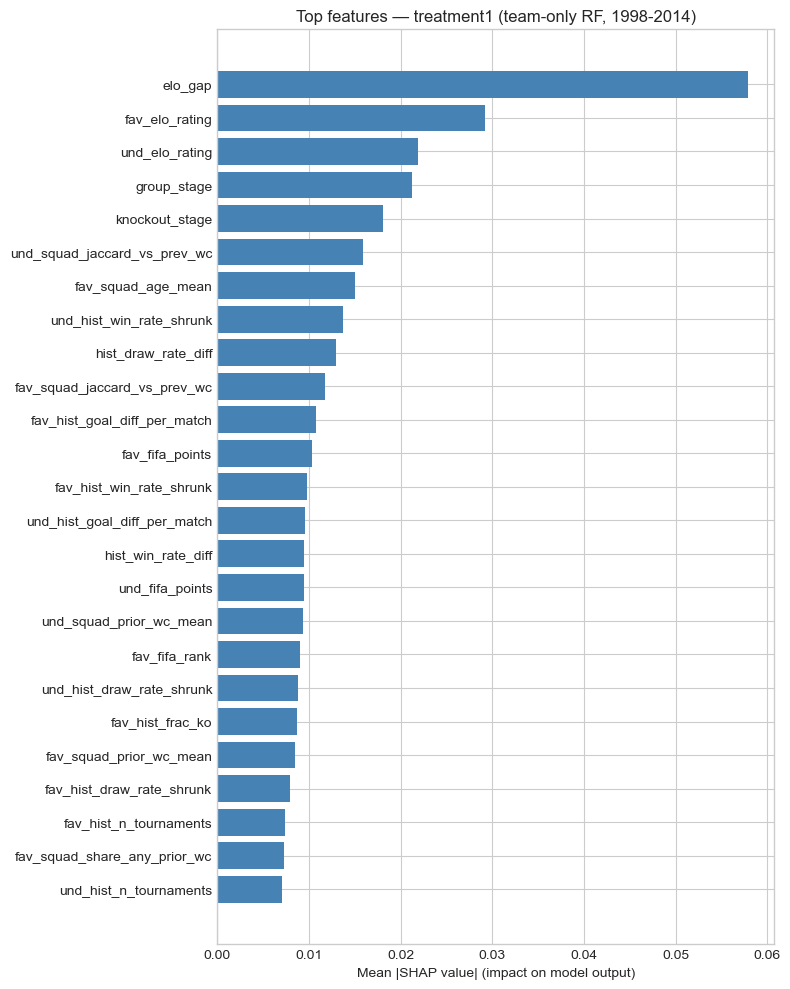


Top 15 features:


,feature,mean_abs_shap
0,elo_gap,0.057877
1,fav_elo_rating,0.029210
2,und_elo_rating,0.021857
3,group_stage,0.021204
4,knockout_stage,0.018047
5,und_squad_jaccard_vs_prev_wc,0.015926
6,fav_squad_age_mean,0.015070
7,und_hist_win_rate_shrunk,0.013736
8,hist_draw_rate_diff,0.012947
9,fav_squad_jaccard_vs_prev_wc,0.011802


In [36]:
def _norm_shap(raw):
    """Normalise SHAP output to list[class] → ndarray(n_samples, n_features).
    SHAP <0.42 returns a list; SHAP ≥0.42 may return ndarray(n_samples, n_features, n_classes).
    """
    if isinstance(raw, np.ndarray) and raw.ndim == 3:
        return [raw[:, :, k] for k in range(raw.shape[2])]
    if isinstance(raw, list):
        return raw
    return [raw]  # binary fallback


X_train_np = imp.transform(train[FEAT_COLS])
explainer = shap.TreeExplainer(model)
shap_values = _norm_shap(explainer.shap_values(X_train_np))

# Mean |SHAP| across all classes → shape (n_features,)
mean_shap = np.mean([np.abs(sv) for sv in shap_values], axis=0).mean(axis=0)
shap_df = pd.DataFrame({"feature": FEAT_COLS, "mean_abs_shap": mean_shap})
shap_df = shap_df.sort_values("mean_abs_shap", ascending=False)

fig, ax = plt.subplots(figsize=(8, 10))
top_n = min(25, len(shap_df))
ax.barh(
    shap_df["feature"].head(top_n)[::-1],
    shap_df["mean_abs_shap"].head(top_n)[::-1],
    color="steelblue",
)
ax.set_xlabel("Mean |SHAP value| (impact on model output)")
ax.set_title("Top features — treatment1 (team-only RF, 1998-2014)")
plt.tight_layout()
plt.savefig(DATA / "shap_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 15 features:")
display(shap_df.head(15).reset_index(drop=True))

### A2 — SHAP beeswarm (direction + magnitude) per class

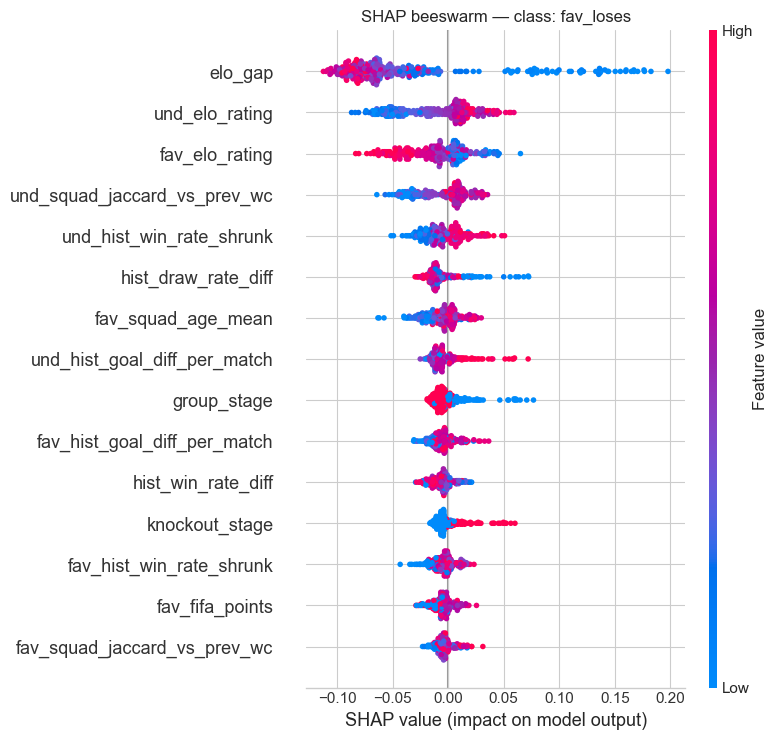

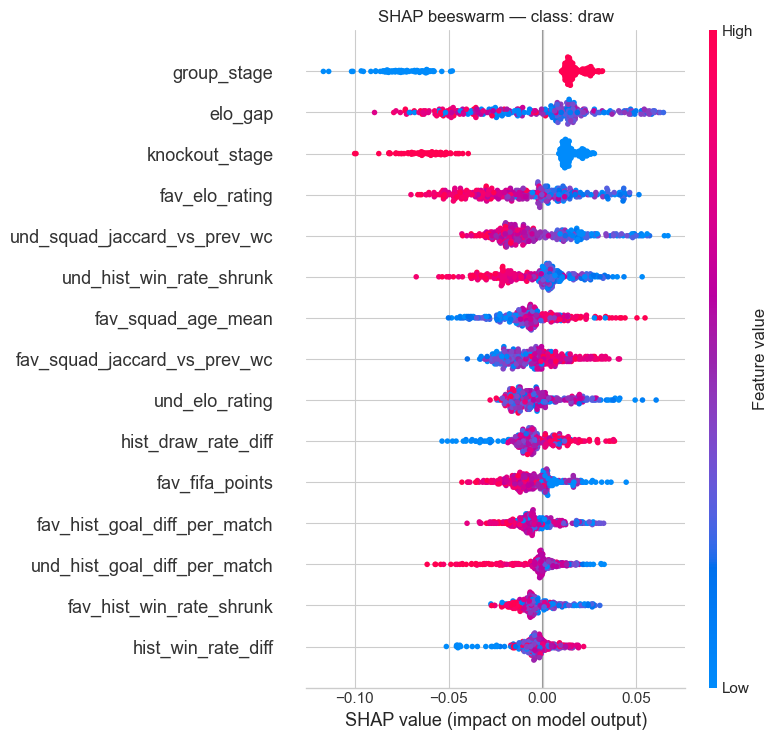

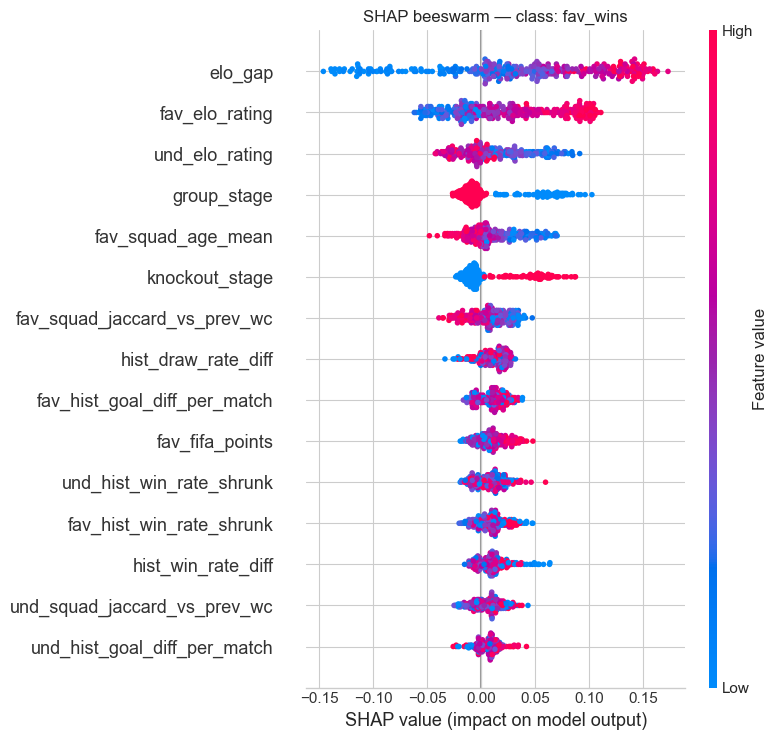

In [37]:
top_features = shap_df["feature"].head(15).tolist()
feat_idx = [FEAT_COLS.index(f) for f in top_features]

class_names = {0: "fav_loses", 1: "draw", 2: "fav_wins"}
for cls_idx, cls_name in class_names.items():
    shap_cls = shap_values[cls_idx][:, feat_idx]
    X_cls = X_train_np[:, feat_idx]
    shap.summary_plot(
        shap_cls,
        X_cls,
        feature_names=top_features,
        show=False,
        plot_type="dot",
        max_display=15,
    )
    plt.title(f"SHAP beeswarm — class: {cls_name}")
    plt.tight_layout()
    plt.savefig(DATA / f"shap_beeswarm_{cls_name}.png", dpi=150, bbox_inches="tight")
    plt.show()

### A3 — SHAP waterfall for specific holdout matches

In [38]:
# Pick 3 illustrative matches: biggest upset, clearest win, a draw
holdout_copy = holdout.copy()
holdout_copy["predicted"] = y_pred
holdout_copy["prob_fav_wins"] = y_prob[:, 2]
holdout_copy["prob_draw"] = y_prob[:, 1]
holdout_copy["prob_fav_loses"] = y_prob[:, 0]

cases = {
    # Match the model correctly predicted as an upset (actual=fav_loses, highest P(fav_loses))
    "Best upset prediction (model correctly called fav_loses)": holdout_copy[
        holdout_copy["y"] == 0
    ]
    .sort_values("prob_fav_loses", ascending=False)
    .index[0],
    # Biggest missed upset — model was most overconfident (actual=fav_loses, highest P(fav_wins))
    "Biggest missed upset (actual=fav_loses, model overconfident)": holdout_copy[
        holdout_copy["y"] == 0
    ]
    .sort_values("prob_fav_wins", ascending=False)
    .index[0],
    "Clearest fav win (fav_wins, high model confidence)": holdout_copy[
        holdout_copy["y"] == 2
    ]
    .sort_values("prob_fav_wins", ascending=False)
    .index[0],
    "Draw": holdout_copy[holdout_copy["y"] == 1]
    .sort_values("prob_draw", ascending=False)
    .index[0],
}

# X_ho_all already computed in Cell 3; re-use explainer from Cell 5
shap_ho = _norm_shap(explainer.shap_values(X_ho_all))

for title, idx in cases.items():
    pos = holdout.index.get_loc(idx)
    row = holdout_copy.loc[idx]
    true_cls = int(row["y"])
    print(f"\n{title}")
    print(
        f"  {row.get('fav_team_name','?')} vs {row.get('und_team_name','?')}  "
        f"({int(row['year'])})  actual={CLASS_LABELS[true_cls]}"
    )
    sv_cls = shap_ho[true_cls][pos]
    top_idx = np.argsort(np.abs(sv_cls))[::-1][:10]
    wf_df = pd.DataFrame(
        {
            "feature": [FEAT_COLS[i] for i in top_idx],
            "shap": sv_cls[top_idx],
        }
    )
    display(wf_df)


Best upset prediction (model correctly called fav_loses)
  England vs Croatia  (2018)  actual=fav_loses


,feature,shap
0,elo_gap,0.116885
1,fav_squad_age_mean,-0.041402
2,und_elo_rating,0.032647
3,group_stage,0.019817
4,fav_fifa_rank,-0.017066
5,hist_draw_rate_diff,-0.014595
6,und_hist_frac_ko,-0.012167
7,fav_fifa_points,-0.012155
8,und_squad_jaccard_vs_prev_wc,0.010858
9,fav_hist_win_rate_shrunk,0.009607



Biggest missed upset (actual=fav_loses, model overconfident)
  Brazil vs Cameroon  (2022)  actual=fav_loses


,feature,shap
0,elo_gap,-0.071334
1,fav_elo_rating,-0.042982
2,und_squad_jaccard_vs_prev_wc,-0.024793
3,und_hist_win_rate_shrunk,-0.022058
4,und_elo_rating,-0.016888
5,hist_draw_rate_diff,-0.013833
6,fav_hist_win_rate_shrunk,-0.008828
7,fav_hist_frac_ko,-0.008017
8,und_hist_goal_diff_per_match,-0.007990
9,fav_mgr_consecutive_wc_with_team,0.007961



Clearest fav win (fav_wins, high model confidence)
  Brazil vs Serbia  (2018)  actual=fav_wins


,feature,shap
0,elo_gap,0.133678
1,fav_elo_rating,0.101962
2,fav_hist_win_rate_shrunk,0.027123
3,fav_hist_goal_diff_per_match,0.023149
4,fav_hist_n_tournaments,0.022901
5,hist_draw_rate_diff,0.022568
6,fav_fifa_points,0.021919
7,fav_squad_jaccard_vs_prev_wc,0.019799
8,und_squad_jaccard_vs_prev_wc,0.019256
9,und_hist_draw_rate_shrunk,0.017235



Draw
  Serbia vs Cameroon  (2022)  actual=draw


,feature,shap
0,fav_fifa_points,-0.049371
1,elo_gap,0.042098
2,und_fifa_points,-0.036636
3,fav_elo_rating,0.025136
4,und_squad_jaccard_vs_prev_wc,0.023293
5,group_stage,0.022618
6,knockout_stage,0.017853
7,und_hist_win_rate_shrunk,0.014967
8,fav_squad_jaccard_vs_prev_wc,0.013699
9,fav_hist_win_rate_shrunk,0.013239


## B — LIME Analysis

Local explanations: for each example match, LIME fits a local linear approximation
around the instance and shows which features drove that specific prediction.


── LIME: Best upset prediction (model correctly called fav_loses) ──
   England vs Croatia (2018)  actual=fav_loses


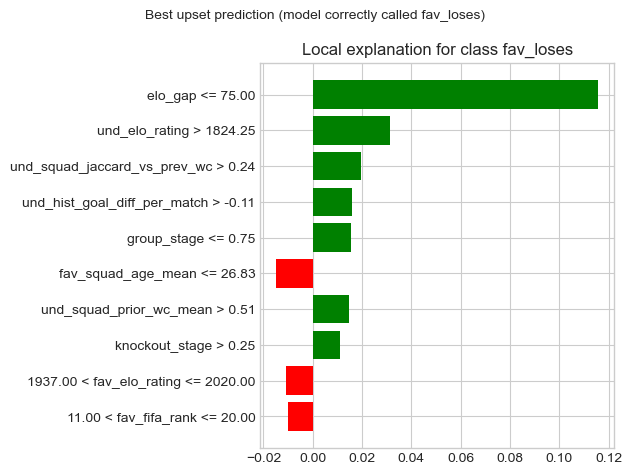


── LIME: Biggest missed upset (actual=fav_loses, model overconfident) ──
   Brazil vs Cameroon (2022)  actual=fav_loses


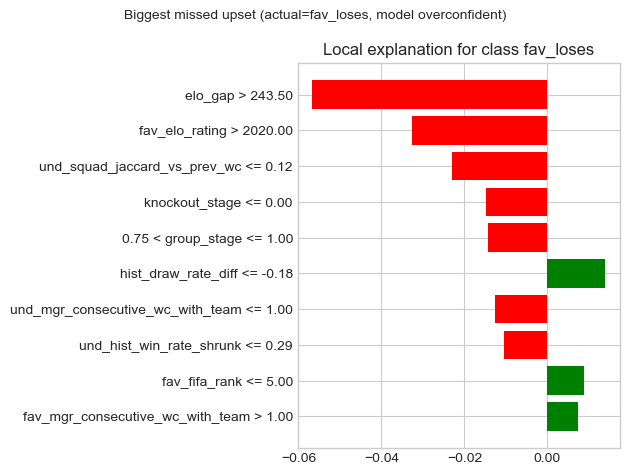


── LIME: Clearest fav win (fav_wins, high model confidence) ──
   Brazil vs Serbia (2018)  actual=fav_wins


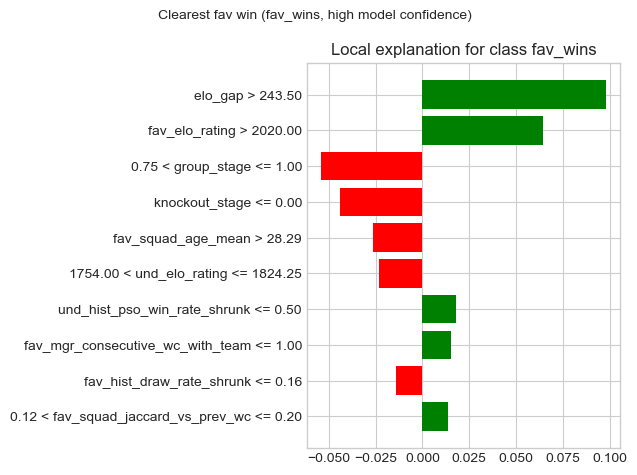


── LIME: Draw ──
   Serbia vs Cameroon (2022)  actual=draw


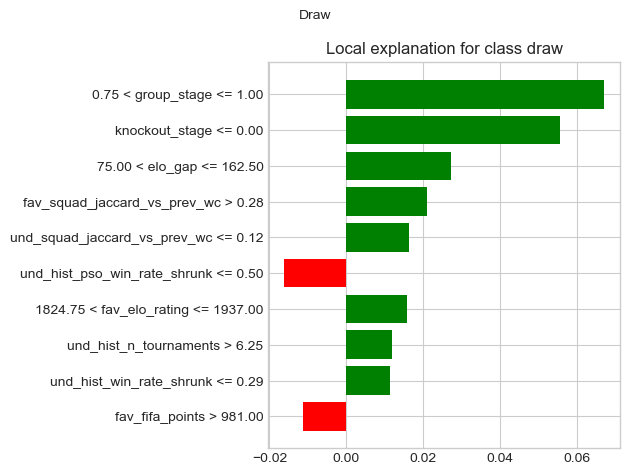

In [39]:
if HAS_LIME:
    explainer_lime = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_train_np,
        feature_names=FEAT_COLS,
        class_names=CLASS_LABELS,
        mode="classification",
        discretize_continuous=True,
        random_state=SEED,
    )

    def predict_fn(X):
        """Wrapper: model already fitted on imputed data; here X is pre-imputed."""
        return model.predict_proba(X)

    for title, idx in cases.items():
        pos = holdout.index.get_loc(idx)
        row = holdout_copy.loc[idx]
        true_cls = int(row["y"])
        instance = X_ho_all[pos]

        exp = explainer_lime.explain_instance(
            data_row=instance,
            predict_fn=predict_fn,
            num_features=10,
            labels=(true_cls,),
        )
        print(f"\n── LIME: {title} ──")
        print(
            f"   {row.get('fav_team_name','?')} vs {row.get('und_team_name','?')} "
            f"({int(row['year'])})  actual={CLASS_LABELS[true_cls]}"
        )
        fig = exp.as_pyplot_figure(label=true_cls)
        fig.suptitle(title, fontsize=10)
        plt.tight_layout()
        fname = (
            title.replace(" ", "_")
            .replace("(", "")
            .replace(")", "")
            .replace(",", "")[:40]
        )
        plt.savefig(DATA / f"lime_{fname}.png", dpi=150, bbox_inches="tight")
        plt.show()
else:
    print("Skipping LIME (not installed). Run: pip install lime")

## C — Report-Inspired Structural Analyses

### C1 — Defending champion effect

The player model report found `defending_champion` survives L1 with a **negative
coefficient** (−0.244, all 3 folds), suggesting title holders underperform
expectations at the next WC. We verify this using SHAP and outcome rates.

In [40]:
# Which column captures defending champion? Check available names.
def_cols = [
    c for c in df_fav.columns if "defending" in c.lower() or "champion" in c.lower()
]
print("Defending champion columns:", def_cols)

if def_cols:
    dc_col = def_cols[0]
    dc_matches = df_fav[df_fav[dc_col] == 1]  # favourite is defending champion
    n_dc = len(dc_matches)
    n_dc_all = (df_fav[dc_col] == 1).sum()
    n_dc_nan = df_fav[dc_col].isna().sum()
    print(f"Defending champion column found: {dc_col}")
    print(f"  Non-null values: {df_fav[dc_col].notna().sum()} / {len(df_fav)}")
    print(f"  NaN (years with no squad data): {n_dc_nan}")
    print(f"  =1 (fav is defending champ): {n_dc_all}")

    if n_dc > 0:
        print("\nOutcome distribution for defending-champion favourites:")
        outcome_dist = dc_matches["y"].value_counts(normalize=True).sort_index()
        outcome_dist.index = [CLASS_LABELS[i] for i in outcome_dist.index]
        display(outcome_dist.to_frame("rate"))

        all_matches_outcome = df_fav["y"].value_counts(normalize=True).sort_index()
        all_matches_outcome.index = [CLASS_LABELS[i] for i in all_matches_outcome.index]
        print("\nBaseline (all matches):")
        display(all_matches_outcome.to_frame("rate"))

        if dc_col in FEAT_COLS:
            dc_idx = FEAT_COLS.index(dc_col)
            shap_dc_wins = shap_values[2][:, dc_idx]
            print(f"\nSHAP (fav_wins class) for {dc_col}:")
            print(f"  mean = {shap_dc_wins.mean():.4f}")
    else:
        print(
            "\n⚠️  No matches found where the *favourite* is the defending champion.\n"
            "   Likely cause: the squad-level 'sq_defending_champion' flag is mostly NaN\n"
            "   (squad data only covers 2006–2022) or the defending champion is frequently\n"
            "   the underdog (lower Elo) in subsequent tournaments (e.g. Italy 2010, Spain 2014).\n"
            "   → Interpretation: this feature carries no signal in the current fav/und framing\n"
            "     and is effectively absent from the model's learned patterns."
        )
else:
    print(
        "No defending champion column found. Run 02_features_player_squad.ipynb first."
    )

Defending champion columns: ['fav_sq_defending_champion', 'und_sq_defending_champion', 'diff_sq_defending_champion']
Defending champion column found: fav_sq_defending_champion
  Non-null values: 320 / 964
  NaN (years with no squad data): 644
  =1 (fav is defending champ): 0

⚠️  No matches found where the *favourite* is the defending champion.
   Likely cause: the squad-level 'sq_defending_champion' flag is mostly NaN
   (squad data only covers 2006–2022) or the defending champion is frequently
   the underdog (lower Elo) in subsequent tournaments (e.g. Italy 2010, Spain 2014).
   → Interpretation: this feature carries no signal in the current fav/und framing
     and is effectively absent from the model's learned patterns.


### C2 — Elo vs squad-quality divergence

Teams where Elo rating and squad club strength **disagree** most — identifying
cases where player-derived features might add signal beyond Elo.

Teams where club quality >> Elo (squad_z - elo_z high, possibly underrated):


,year,fav_team_name,fav_elo_rating,fav_pl_squad_avg_strength,divergence
0,2014,Spain,1954.0,1968.025921,2.083342
1,2010,France,1802.0,1845.062276,1.971416
2,2006,Mexico,1817.0,1850.347229,1.908920
3,2010,Ivory Coast,1716.0,1767.036724,1.817322
4,2006,Spain,1884.0,1861.838272,1.499696
5,2006,South Korea,1668.0,1701.582423,1.496130
6,2006,Serbia and Montenegro,1791.0,1786.884399,1.434226
7,2018,Egypt,1617.0,1645.904818,1.303753



Teams where Elo >> club quality (possibly overrated):


,year,fav_team_name,fav_elo_rating,fav_pl_squad_avg_strength,divergence
0,2022,Australia,1772.0,1456.031564,-1.966970
1,2018,Iran,1823.0,1517.824238,-1.708938
2,2010,Netherlands,2105.0,1738.201891,-1.584518
3,2014,Colombia,2019.0,1677.194755,-1.555893
4,2014,Netherlands,2030.0,1693.180583,-1.471701
5,2006,Poland,1780.0,1510.522412,-1.445518
6,2018,Peru,1854.0,1566.864872,-1.428835
7,2022,Argentina,2143.0,1783.977669,-1.395114


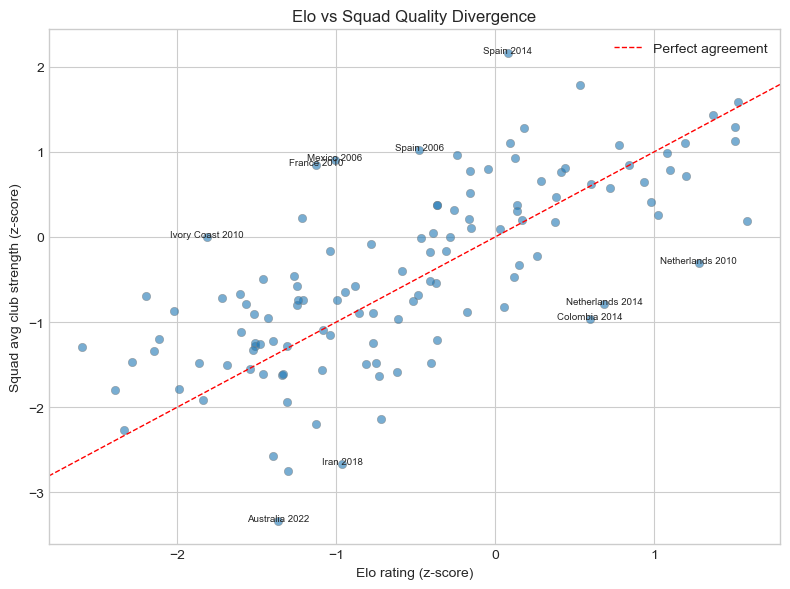

In [41]:
if "fav_pl_squad_avg_strength" in df_fav.columns and "fav_elo_rating" in df_fav.columns:
    # Normalise both to z-scores for comparability
    from scipy.stats import zscore

    div_df = df_fav[
        [
            "tournament_id",
            "year",
            "fav_team_name",
            "fav_elo_rating",
            "fav_pl_squad_avg_strength",
            "y",
        ]
    ].copy()
    div_df = div_df.dropna(subset=["fav_elo_rating", "fav_pl_squad_avg_strength"])
    div_df["elo_z"] = zscore(div_df["fav_elo_rating"])
    div_df["squad_z"] = zscore(div_df["fav_pl_squad_avg_strength"])
    div_df["divergence"] = div_df["squad_z"] - div_df["elo_z"]

    # Collapse to team×tournament (one row per team)
    team_div = div_df.drop_duplicates(subset=["tournament_id", "fav_team_name"]).copy()

    print(
        "Teams where club quality >> Elo (squad_z - elo_z high, possibly underrated):"
    )
    display(
        team_div.sort_values("divergence", ascending=False)[
            [
                "year",
                "fav_team_name",
                "fav_elo_rating",
                "fav_pl_squad_avg_strength",
                "divergence",
            ]
        ]
        .head(8)
        .reset_index(drop=True)
    )

    print("\nTeams where Elo >> club quality (possibly overrated):")
    display(
        team_div.sort_values("divergence", ascending=True)[
            [
                "year",
                "fav_team_name",
                "fav_elo_rating",
                "fav_pl_squad_avg_strength",
                "divergence",
            ]
        ]
        .head(8)
        .reset_index(drop=True)
    )

    # Scatter plot
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(
        team_div["elo_z"],
        team_div["squad_z"],
        alpha=0.6,
        edgecolors="gray",
        linewidths=0.5,
    )
    ax.axline(
        (0, 0),
        slope=1,
        color="red",
        linestyle="--",
        linewidth=1,
        label="Perfect agreement",
    )
    top_div = team_div.nlargest(5, "divergence")
    bot_div = team_div.nsmallest(5, "divergence")
    for _, r in pd.concat([top_div, bot_div]).iterrows():
        ax.annotate(
            f"{r['fav_team_name']} {int(r['year'])}",
            (r["elo_z"], r["squad_z"]),
            fontsize=7,
            ha="center",
        )
    ax.set_xlabel("Elo rating (z-score)")
    ax.set_ylabel("Squad avg club strength (z-score)")
    ax.set_title("Elo vs Squad Quality Divergence")
    ax.legend()
    plt.tight_layout()
    plt.savefig(DATA / "elo_vs_squad_divergence.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print(
        "Player squad features not available. Run 02_features_player_squad.ipynb first."
    )

### C3 — Geographic coverage bias

The player model report highlighted that AFC and CONCACAF squads have 18% and
14% missing club stats respectively. We quantify whether our model's errors
are **systematically concentrated** in those confederations.

Holdout accuracy by fav-team confederation:


,accuracy,n_matches
fav_conf,,
CONCACAF,0.400000,5
AFC,0.600000,5
UEFA,0.650000,80
CONMEBOL,0.677419,31
CAF,0.714286,7


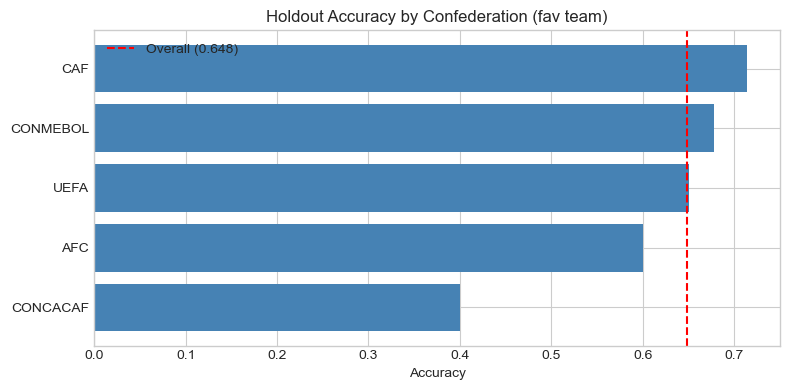


Player-feature coverage by confederation:


,coverage
fav_conf,
AFC,1.0
CAF,1.0
CONCACAF,1.0
CONMEBOL,1.0
UEFA,1.0


In [42]:
holdout_copy["correct"] = (holdout_copy["predicted"] == holdout_copy["y"]).astype(int)

# Confederation ID → human-readable code (from DB confederations table)
CONF_CODE_MAP = {
    "CF-1": "AFC",
    "CF-2": "CAF",
    "CF-3": "CONCACAF",
    "CF-4": "CONMEBOL",
    "CF-5": "OFC",
    "CF-6": "UEFA",
}

# Attach confederation info for fav team
conf_map = teams_db.set_index("team_id")["confederation_id"].to_dict()
holdout_copy["fav_conf_id"] = holdout_copy["fav_team_id"].map(conf_map)
holdout_copy["und_conf_id"] = holdout_copy["und_team_id"].map(conf_map)
holdout_copy["fav_conf"] = (
    holdout_copy["fav_conf_id"].map(CONF_CODE_MAP).fillna(holdout_copy["fav_conf_id"])
)
holdout_copy["und_conf"] = (
    holdout_copy["und_conf_id"].map(CONF_CODE_MAP).fillna(holdout_copy["und_conf_id"])
)

# Accuracy by fav team confederation
conf_acc = (
    holdout_copy.groupby("fav_conf")["correct"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "accuracy", "count": "n_matches"})
    .sort_values("accuracy")
)
print("Holdout accuracy by fav-team confederation:")
display(conf_acc)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(conf_acc.index, conf_acc["accuracy"], color="steelblue")
ax.axvline(
    holdout_copy["correct"].mean(),
    color="red",
    linestyle="--",
    label=f"Overall ({holdout_copy['correct'].mean():.3f})",
)
ax.set_xlabel("Accuracy")
ax.set_title("Holdout Accuracy by Confederation (fav team)")
ax.legend()
plt.tight_layout()
plt.savefig(DATA / "accuracy_by_confederation.png", dpi=150, bbox_inches="tight")
plt.show()

# Player data coverage by confederation
if "fav_pl_squad_avg_strength" in holdout_copy.columns:
    cov = (
        holdout_copy.groupby("fav_conf")["fav_pl_squad_avg_strength"]
        .apply(lambda x: x.notna().mean())
        .sort_values()
    )
    print("\nPlayer-feature coverage by confederation:")
    display(cov.to_frame("coverage"))

---
## D — Edge Case Analysis: Upset Explanation

**Motivation:** `treatment2` (team + player/squad features) did not improve
aggregate holdout metrics over `treatment1` (team-only). However, aggregate
metrics average over 128 matches and may obscure cases where player-level
information *does* add explanatory value for individual, historically significant matches.

**Design:**
1. Identify the biggest *upsets* in the 2018 + 2022 holdout — matches where the
   model was highly confident in `fav_wins` but the actual outcome was `fav_loses`.
2. For each upset, compare `treatment1` vs `treatment2` probability estimates —
   does the richer model assign *less* confidence to the favourite?
3. Inspect which **player/squad features** drove any difference via SHAP waterfall.
4. Cross-check against known football context (defending champion, squad cohesion,
   club Elo divergence) to test whether features carry the right narrative.

> **Honesty anchor:** Both models likely mis-predicted most upsets.
> The goal is not to claim treatment2 is better, but to ask:
> *"Does it at least understand the upset better, even if it still got it wrong?"*

### D1 — Identify upsets in holdout

An *upset* here = actual outcome is `fav_loses` (0) while `treatment1` model
assigned highest probability to `fav_wins` (2). We rank by the model's confidence
in the wrong direction.

In [43]:
# Re-load team name lookup for readable labels
import sqlite3

_con = sqlite3.connect(DB_PATH)
teams_lookup = (
    pd.read_sql_query("SELECT team_id, team_name FROM teams", _con)
    .set_index("team_id")["team_name"]
    .to_dict()
)
_con.close()

# Refit treatment1 and treatment2 models (self-contained — 04 may run standalone)
# treatment1: team-only, 1998-2014
# treatment2: team+player/squad, 2006-2014
HOLDOUT_YEARS = [2018, 2022]
SEED = 42

from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import lightgbm as lgb
import xgboost as xgb

# Feature columns (mirrors 03_model_training B3)
TEAM_HIST_COLS = [
    "fav_hist_win_rate_shrunk",
    "und_hist_win_rate_shrunk",
    "fav_hist_draw_rate_shrunk",
    "und_hist_draw_rate_shrunk",
    "fav_hist_ko_win_rate_shrunk",
    "und_hist_ko_win_rate_shrunk",
    "fav_hist_goal_diff_per_match",
    "und_hist_goal_diff_per_match",
    "fav_hist_frac_ko",
    "und_hist_frac_ko",
    "fav_hist_n_tournaments",
    "und_hist_n_tournaments",
    "fav_hist_pso_win_rate_shrunk",
    "und_hist_pso_win_rate_shrunk",
    "hist_win_rate_diff",
    "hist_draw_rate_diff",
    "elo_gap",
    "abs_elo_gap",
]
TEAM_SQUAD_COLS = [
    "fav_squad_age_mean",
    "und_squad_age_mean",
    "fav_squad_prior_wc_mean",
    "und_squad_prior_wc_mean",
    "fav_squad_share_any_prior_wc",
    "und_squad_share_any_prior_wc",
    "fav_squad_jaccard_vs_prev_wc",
    "und_squad_jaccard_vs_prev_wc",
]
TEAM_COACH_COLS = [
    "fav_manager_local",
    "und_manager_local",
    "fav_mgr_n_prior_wc",
    "und_mgr_n_prior_wc",
    "fav_mgr_hist_win_rate_shrunk",
    "und_mgr_hist_win_rate_shrunk",
    "fav_mgr_consecutive_wc_with_team",
    "und_mgr_consecutive_wc_with_team",
]
TEAM_RANK_COLS = [
    "fav_elo_rating",
    "und_elo_rating",
    "fav_fifa_rank",
    "und_fifa_rank",
    "fav_fifa_points",
    "und_fifa_points",
]
MATCH_COLS = [
    "fav_is_home",
    "group_stage",
    "knockout_stage",
    "feat_home_is_host",
    "feat_away_is_host",
    "feat_same_confederation",
    "rest_days_diff",
]
PLAYER_COLS = [
    c for c in df_fav.columns if c.startswith("fav_pl_") or c.startswith("und_pl_")
]
SQUAD_COLS = [
    c for c in df_fav.columns if c.startswith("fav_sq_") or c.startswith("und_sq_")
]
DIFF_COLS = [c for c in df_fav.columns if c.startswith("diff_")]

CONFIG_A = [
    c
    for c in TEAM_HIST_COLS
    + TEAM_SQUAD_COLS
    + TEAM_COACH_COLS
    + TEAM_RANK_COLS
    + MATCH_COLS
    if c in df_fav.columns
]
CONFIG_B = [
    c for c in CONFIG_A + PLAYER_COLS + SQUAD_COLS + DIFF_COLS if c in df_fav.columns
]

# Fit RF on treatment1 (CONFIG_A, 1998-2014)
_rf_proto = Pipeline(
    [
        ("imp", SimpleImputer()),
        (
            "clf",
            RandomForestClassifier(
                n_estimators=300,
                class_weight="balanced",
                random_state=SEED,
                n_jobs=-1,
            ),
        ),
    ]
)
train_t1 = df_fav[(df_fav["year"] >= 1998) & (~df_fav["year"].isin(HOLDOUT_YEARS))]
model_t1 = clone(_rf_proto)
model_t1.fit(train_t1[CONFIG_A], train_t1["y"])

# Fit XGB on treatment2 (CONFIG_B, 2006-2014)
_xgb_proto = Pipeline(
    [
        ("imp", SimpleImputer()),
        (
            "clf",
            xgb.XGBClassifier(
                n_estimators=300,
                learning_rate=0.05,
                use_label_encoder=False,
                eval_metric="mlogloss",
                random_state=SEED,
                verbosity=0,
            ),
        ),
    ]
)
train_t2 = df_fav[(df_fav["year"] >= 2006) & (~df_fav["year"].isin(HOLDOUT_YEARS))]
model_t2 = clone(_xgb_proto)
model_t2.fit(train_t2[CONFIG_B], train_t2["y"])

print(f"treatment1 RF fitted on {len(train_t1)} rows, {len(CONFIG_A)} features")
print(f"treatment2 XGB fitted on {len(train_t2)} rows, {len(CONFIG_B)} features")

# Holdout predictions
holdout = df_fav[df_fav["year"].isin(HOLDOUT_YEARS)].copy()
prob_t1 = model_t1.predict_proba(holdout[CONFIG_A])
prob_t2 = model_t2.predict_proba(holdout[CONFIG_B])

holdout["t1_pred"] = prob_t1.argmax(axis=1)
holdout["t1_prob_fav_wins"] = prob_t1[:, 2]
holdout["t1_prob_draw"] = prob_t1[:, 1]
holdout["t1_prob_fav_loses"] = prob_t1[:, 0]
holdout["t2_pred"] = prob_t2.argmax(axis=1)
holdout["t2_prob_fav_wins"] = prob_t2[:, 2]
holdout["t2_prob_draw"] = prob_t2[:, 1]
holdout["t2_prob_fav_loses"] = prob_t2[:, 0]

# Identify upsets: actual = fav_loses (0), but t1 predicted fav_wins
upsets = holdout[
    (holdout["y"] == 0)  # underdog actually won
    & (holdout["t1_pred"] == 2)  # treatment1 was wrong (predicted fav_wins)
].copy()

upsets["t1_confidence"] = upsets["t1_prob_fav_wins"]  # how wrong was t1?
upsets["t2_confidence"] = upsets["t2_prob_fav_wins"]  # was t2 less wrong?
upsets["t2_more_cautious"] = upsets["t2_confidence"] < upsets["t1_confidence"]
upsets["confidence_drop"] = upsets["t1_confidence"] - upsets["t2_confidence"]

# Add team name labels
upsets["fav_name"] = upsets["fav_team_id"].map(teams_lookup)
upsets["und_name"] = upsets["und_team_id"].map(teams_lookup)

display_cols = [
    "year",
    "fav_name",
    "und_name",
    "t1_confidence",
    "t2_confidence",
    "confidence_drop",
    "t2_more_cautious",
]

print(f"Upsets (t1 predicted fav_wins, actual = fav_loses): {len(upsets)} matches\n")
display(
    upsets[display_cols]
    .sort_values("t1_confidence", ascending=False)
    .reset_index(drop=True)
    .style.format(
        {
            "t1_confidence": "{:.3f}",
            "t2_confidence": "{:.3f}",
            "confidence_drop": "{:.3f}",
        }
    )
    .background_gradient(subset=["confidence_drop"], cmap="RdYlGn")
)

treatment1 RF fitted on 320 rows, 47 features
treatment2 XGB fitted on 192 rows, 110 features
Upsets (t1 predicted fav_wins, actual = fav_loses): 23 matches



,year,fav_name,und_name,t1_confidence,t2_confidence,confidence_drop,t2_more_cautious
0,2022,Brazil,Cameroon,0.873,0.990,-0.117,False
1,2018,Spain,Russia,0.857,0.965,-0.108,False
2,2018,Brazil,Belgium,0.857,0.962,-0.106,False
3,2022,Spain,Morocco,0.843,0.983,-0.140,False
4,2022,Portugal,Morocco,0.840,0.985,-0.145,False
5,2022,Brazil,Croatia,0.830,0.993,-0.163,False
6,2022,France,Tunisia,0.817,0.948,-0.131,False
7,2022,Argentina,Saudi Arabia,0.773,0.712,0.061,True
8,2018,Colombia,Japan,0.737,0.998,-0.261,False
9,2018,Switzerland,Sweden,0.700,0.866,-0.166,False


### D2 — Does treatment2 assign lower confidence to favourites in upsets?

For each upset, we compare the favourite's win probability under `treatment1`
(team-only) vs `treatment2` (team + player/squad).

A **positive `confidence_drop`** means treatment2 "hedged more" —
it was less certain the favourite would win, giving it a lower probability.
This suggests the player/squad features detected something that team-Elo alone missed.

We then inspect the top-3 most dramatic upsets in detail.

Upsets where t2 was more cautious than t1: 4/23 (17%)
Mean confidence drop (t1 - t2) across upsets: -0.169



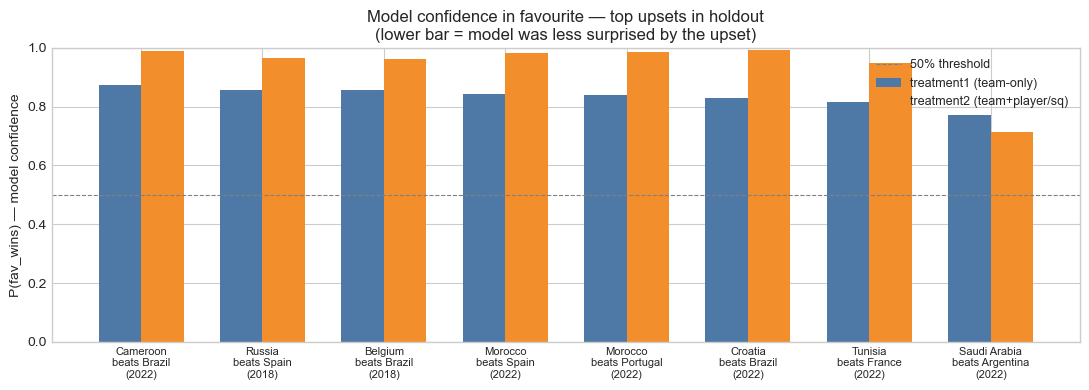

In [44]:
# Summary statistics across all upsets
n_more_cautious = upsets["t2_more_cautious"].sum()
mean_drop = upsets["confidence_drop"].mean()

print(
    f"Upsets where t2 was more cautious than t1: "
    f"{n_more_cautious}/{len(upsets)} ({100*n_more_cautious/len(upsets):.0f}%)"
)
print(f"Mean confidence drop (t1 - t2) across upsets: {mean_drop:+.3f}")
print()

# Bar chart: t1 vs t2 win probability for each upset
top_upsets = upsets.sort_values("t1_confidence", ascending=False).head(8)
fig, ax = plt.subplots(figsize=(11, 4))
x = range(len(top_upsets))
w = 0.35
labels = [
    f"{r['und_name']}\nbeats {r['fav_name']}\n({int(r['year'])})"
    for _, r in top_upsets.iterrows()
]
ax.bar(
    [i - w / 2 for i in x],
    top_upsets["t1_confidence"],
    w,
    label="treatment1 (team-only)",
    color="#4e79a7",
)
ax.bar(
    [i + w / 2 for i in x],
    top_upsets["t2_confidence"],
    w,
    label="treatment2 (team+player/sq)",
    color="#f28e2b",
)
ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="50% threshold")
ax.set_xticks(list(x))
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("P(fav_wins) — model confidence")
ax.set_title(
    "Model confidence in favourite — top upsets in holdout\n"
    "(lower bar = model was less surprised by the upset)"
)
ax.legend(loc="upper right", fontsize=9)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(DATA / "upset_confidence_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### D3 — Deep dive: top 3 upsets, feature-level comparison

For the three biggest upsets (highest model confidence in wrong direction),
we show the raw feature values for both teams and explain the narrative.

In [45]:
# Top 3 upsets by t1 confidence
top3 = upsets.sort_values("t1_confidence", ascending=False).head(3)

# Features to spotlight (most interpretable diff features)
SPOTLIGHT_FEATS = [
    "elo_gap",
    "abs_elo_gap",
    "fav_elo_rating",
    "und_elo_rating",
    "fav_hist_win_rate_shrunk",
    "und_hist_win_rate_shrunk",
    "fav_hist_draw_rate_shrunk",
    "und_hist_draw_rate_shrunk",
    "fav_squad_prior_wc_mean",
    "und_squad_prior_wc_mean",
    "fav_squad_share_any_prior_wc",
    "und_squad_share_any_prior_wc",
    "fav_mgr_hist_win_rate_shrunk",
    "und_mgr_hist_win_rate_shrunk",
    "fav_hist_n_tournaments",
    "und_hist_n_tournaments",
    "group_stage",
    "knockout_stage",
    "rest_days_diff",
]
# Also include player cols if available
pl_spotlight = [
    c
    for c in [
        "fav_pl_squad_avg_strength",
        "und_pl_squad_avg_strength",
        "fav_pl_squad_goals_adj",
        "und_pl_squad_goals_adj",
        "fav_sq_wc_pedigree_mean",
        "und_sq_wc_pedigree_mean",
        "fav_sq_club_cohesion",
        "und_sq_club_cohesion",
    ]
    if c in df_fav.columns
]
SPOTLIGHT_FEATS = [f for f in SPOTLIGHT_FEATS + pl_spotlight if f in holdout.columns]

for rank, (_, row) in enumerate(top3.iterrows(), 1):
    fav = row.get("fav_name", row.get("fav_team_id", "?"))
    und = row.get("und_name", row.get("und_team_id", "?"))
    yr = int(row["year"])

    print(f"\n{'='*65}")
    print(f"Upset #{rank}: {und} beats {fav}  ({yr})")
    print(
        f"  treatment1 P(fav_wins) = {row['t1_confidence']:.3f}  "
        f"(predicted: fav_wins ✗)"
    )
    print(
        f"  treatment2 P(fav_wins) = {row['t2_confidence']:.3f}  "
        f"({'more cautious ✓' if row['t2_more_cautious'] else 'also overconfident ✗'})"
    )
    print(f"  Confidence drop        = {row['confidence_drop']:+.3f}\n")

    feat_vals = {}
    for f in SPOTLIGHT_FEATS:
        val = row.get(f, np.nan)
        if not pd.isna(val):
            feat_vals[f] = val

    feat_df = pd.Series(feat_vals, name="value").rename_axis("feature").reset_index()
    # Split into fav/und pairs for readability
    fav_feats = feat_df[feat_df["feature"].str.startswith("fav_")].copy()
    und_feats = feat_df[feat_df["feature"].str.startswith("und_")].copy()
    diff_feats = feat_df[~feat_df["feature"].str.startswith(("fav_", "und_"))].copy()

    if len(diff_feats):
        print("Match-level features:")
        print(diff_feats.to_string(index=False))
    if len(fav_feats) and len(und_feats):
        fav_feats["feature"] = fav_feats["feature"].str.replace("fav_", "", 1)
        und_feats["feature"] = und_feats["feature"].str.replace("und_", "", 1)
        merged = fav_feats.merge(
            und_feats, on="feature", suffixes=(f" ({fav})", f" ({und})")
        )
        print(f"\nFav vs Und features (fav={fav}, und={und}):")
        print(merged.to_string(index=False))


Upset #1: Cameroon beats Brazil  (2022)
  treatment1 P(fav_wins) = 0.873  (predicted: fav_wins ✗)
  treatment2 P(fav_wins) = 0.990  (also overconfident ✗)
  Confidence drop        = -0.117

Match-level features:
       feature  value
       elo_gap  455.0
   abs_elo_gap  455.0
   group_stage    1.0
knockout_stage    0.0
rest_days_diff    0.0

Fav vs Und features (fav=Brazil, und=Cameroon):
                 feature  value (Brazil)  value (Cameroon)
              elo_rating     2134.000000       1679.000000
    hist_win_rate_shrunk        0.690265          0.222222
   hist_draw_rate_shrunk        0.141593          0.333333
     squad_prior_wc_mean        0.538462          0.230769
squad_share_any_prior_wc        0.384615          0.115385
mgr_hist_win_rate_shrunk        0.555556          0.500000
      hist_n_tournaments       21.000000          7.000000
   pl_squad_avg_strength     1871.899214       1644.208924
      pl_squad_goals_adj        0.158991          0.112321

Upset #2: Russi

### D4 — SHAP waterfall: treatment1 vs treatment2 on the biggest upset

SHAP waterfall plots show which features *pushed* the model toward or away from
`fav_wins` for a specific match. Comparing the two models side-by-side reveals
which player/squad features added (or missed) signal.

> If treatment2 shows squad/player features with large negative SHAP values
> (pushing toward `fav_loses`), it means those features were "seeing" the upset —
> even if not strongly enough to change the final prediction.

Biggest upset: Cameroon beats Brazil (2022)
  t1 P(fav_wins)=0.873  t2 P(fav_wins)=0.990


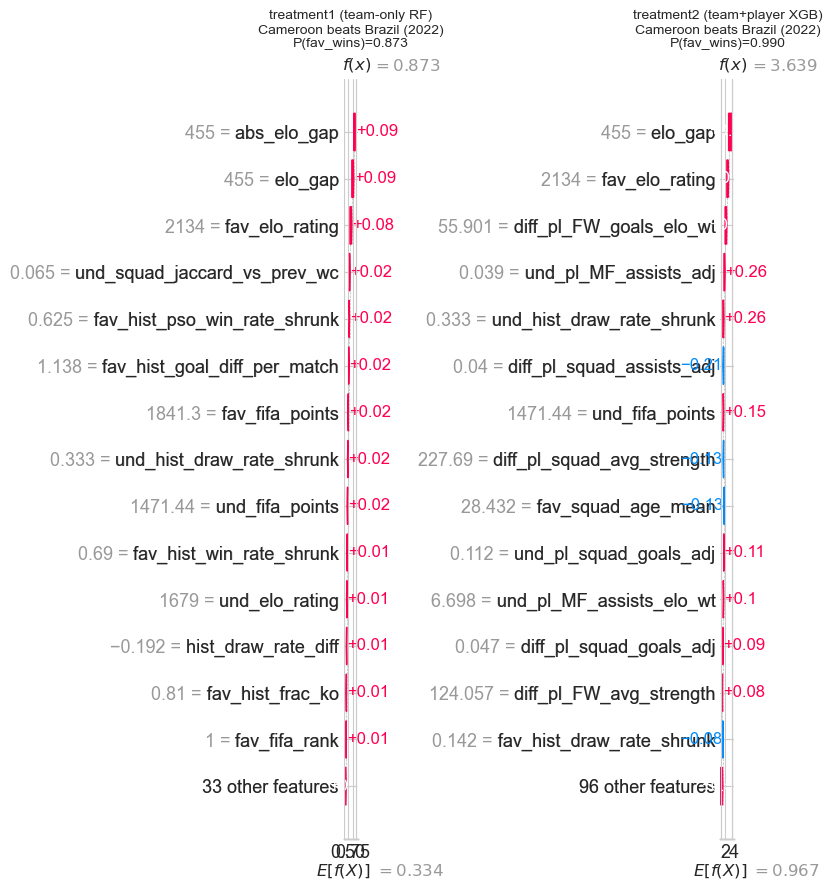

In [46]:
try:
    import shap as _shap

    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
    print("shap not installed — skipping D4")

if HAS_SHAP:
    # Pick the single biggest upset (highest t1 confidence in wrong direction)
    upset_row = upsets.sort_values("t1_confidence", ascending=False).iloc[0]
    idx_in_holdout = upset_row.name  # original df_fav index

    fav_name = upset_row.get("fav_name", "Favourite")
    und_name = upset_row.get("und_name", "Underdog")
    yr = int(upset_row["year"])

    print(f"Biggest upset: {und_name} beats {fav_name} ({yr})")
    print(
        f"  t1 P(fav_wins)={upset_row['t1_confidence']:.3f}  "
        f"t2 P(fav_wins)={upset_row['t2_confidence']:.3f}"
    )

    def _norm_shap_local(raw):
        if isinstance(raw, np.ndarray) and raw.ndim == 3:
            return [raw[:, :, k] for k in range(raw.shape[2])]
        return raw if isinstance(raw, list) else [raw]

    # ── treatment1 SHAP (RF) ─────────────────────────────────────────────
    imp_t1 = model_t1.named_steps["imp"]
    X_upset_t1_imp = imp_t1.transform(holdout.loc[[idx_in_holdout], CONFIG_A])
    explainer_t1 = _shap.TreeExplainer(model_t1.named_steps["clf"])
    shap_t1 = _norm_shap_local(explainer_t1.shap_values(X_upset_t1_imp))
    sv_t1 = _shap.Explanation(
        values=shap_t1[2][0],
        base_values=explainer_t1.expected_value[2],
        data=X_upset_t1_imp[0],
        feature_names=CONFIG_A,
    )

    # ── treatment2 SHAP (XGB) ────────────────────────────────────────────
    imp_t2 = model_t2.named_steps["imp"]
    X_upset_t2_imp = imp_t2.transform(holdout.loc[[idx_in_holdout], CONFIG_B])
    explainer_t2 = _shap.TreeExplainer(model_t2.named_steps["clf"])
    shap_t2 = _norm_shap_local(explainer_t2.shap_values(X_upset_t2_imp))
    sv_t2 = _shap.Explanation(
        values=shap_t2[2][0],
        base_values=explainer_t2.expected_value[2],
        data=X_upset_t2_imp[0],
        feature_names=CONFIG_B,
    )

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    plt.sca(axes[0])
    _shap.waterfall_plot(sv_t1, max_display=15, show=False)
    axes[0].set_title(
        f"treatment1 (team-only RF)\n{und_name} beats {fav_name} ({yr})\n"
        f"P(fav_wins)={upset_row['t1_confidence']:.3f}",
        fontsize=10,
    )
    plt.sca(axes[1])
    _shap.waterfall_plot(sv_t2, max_display=15, show=False)
    axes[1].set_title(
        f"treatment2 (team+player XGB)\n{und_name} beats {fav_name} ({yr})\n"
        f"P(fav_wins)={upset_row['t2_confidence']:.3f}",
        fontsize=10,
    )
    plt.tight_layout()
    plt.savefig(
        DATA / "shap_waterfall_upset_comparison.png", dpi=150, bbox_inches="tight"
    )
    plt.show()

### D5 — Interpretation narrative

**What to look for in the SHAP waterfalls:**

| Signal | What it means |
|--------|---------------|
| `elo_gap` large positive (t1) | Team-only model attributes most confidence to Elo gap — misses non-Elo factors |
| Player features negative (t2) | `und_pl_squad_avg_strength`, `und_sq_wc_pedigree_mean` etc. pushing *against* fav_wins — the model "noticed" the underdog's quality |
| `fav_hist_draw_rate_shrunk` | Favourite historically draws more often → softens win confidence |
| `und_squad_prior_wc_mean` | Underdog squad has more WC experience → reduces upset factor |
| `fav_mgr_hist_win_rate_shrunk` | Favourite's manager win rate → if low, adds doubt |

**Key question:** Do the player/squad features in treatment2 show meaningful
negative SHAP values (pushing toward `fav_loses`) for the upset match?
If yes, they contain *local signal* that aggregate metrics don't capture.
If no, the upset was truly unpredictable from pre-match data.

---
## E — Stage-wise Analysis: Group Stage vs Knockout

**Motivation:** The World Cup has two structurally distinct phases:

| Phase | Characteristics |
|---|---|
| **Group stage** | Fixed matchups, limited stakes, possible tactical resting, 3 games per team |
| **Knockout** | Single-elimination, high pressure, extra time / penalties possible |

Individual **player quality** is hypothesised to matter more in knockout rounds (fewer games, high variance), while **historical team strength** (Elo) is more stable across group stage. If this hypothesis holds, `treatment2` (with player/squad features) should show a comparative advantage specifically in knockout matches.

**Design:**
1. Split holdout into `group_stage` and `knockout_stage` matches.
2. For each stage: accuracy, macro-F1, macro-AUC — compare `treatment1` vs `treatment2`.
3. Examine upset rate and model confidence patterns within each stage.
4. Plot per-stage confusion matrices to pinpoint where each model fails.

### E1 — Refit both models on holdout split by stage

In [47]:
from sklearn.base import clone
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

CLASS_LABELS_E = {0: "fav_loses", 1: "draw", 2: "fav_wins"}

# ── Feature sets (mirrors 03_model_training) ───────────────────────────
# treatment1: team-only (same as FEAT_COLS above)
T1_FEAT = FEAT_COLS

# treatment2: team + player/squad features
PLAYER_COLS = [
    c
    for c in df_fav.columns
    if c.startswith("fav_pl_")
    or c.startswith("und_pl_")
    or c.startswith("fav_sq_")
    or c.startswith("und_sq_")
]
SQUAD_EXTRA = [
    "fav_squad_age_mean",
    "und_squad_age_mean",
    "fav_squad_prior_wc_mean",
    "und_squad_prior_wc_mean",
    "fav_squad_share_any_prior_wc",
    "und_squad_share_any_prior_wc",
    "fav_squad_jaccard_vs_prev_wc",
    "und_squad_jaccard_vs_prev_wc",
]
T2_FEAT = [c for c in list(dict.fromkeys(T1_FEAT + PLAYER_COLS)) if c in df_fav.columns]

# ── Train/holdout splits ───────────────────────────────────────────────
# treatment1: 1998-2014 training window
train_t1 = df_fav[
    (df_fav["year"] >= 1998) & (~df_fav["year"].isin(HOLDOUT_YEARS))
].copy()
# treatment2: 2006-2014 training window (player data only from 2006)
train_t2 = df_fav[
    (df_fav["year"] >= 2006) & (~df_fav["year"].isin(HOLDOUT_YEARS))
].copy()
holdout_e = df_fav[df_fav["year"].isin(HOLDOUT_YEARS)].copy()

# ── Fit models ────────────────────────────────────────────────────────
pipe_t1 = Pipeline(
    [
        ("imp", SimpleImputer()),
        (
            "clf",
            RandomForestClassifier(
                n_estimators=300, class_weight="balanced", random_state=SEED, n_jobs=-1
            ),
        ),
    ]
)
pipe_t1.fit(train_t1[T1_FEAT], train_t1["y"])

pipe_t2 = Pipeline(
    [
        ("imp", SimpleImputer()),
        (
            "clf",
            xgb.XGBClassifier(
                n_estimators=300,
                max_depth=4,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                use_label_encoder=False,
                eval_metric="mlogloss",
                random_state=SEED,
                n_jobs=-1,
            ),
        ),
    ]
)
pipe_t2.fit(train_t2[T2_FEAT], train_t2["y"])

# ── Stage masks ───────────────────────────────────────────────────────
group_mask = holdout_e["group_stage"].fillna(0).astype(bool)
knockout_mask = holdout_e["knockout_stage"].fillna(0).astype(bool)
stage_masks = {
    "group_stage": group_mask,
    "knockout_stage": knockout_mask,
    "all": pd.Series([True] * len(holdout_e), index=holdout_e.index),
}

print(
    f"Holdout  : {len(holdout_e)} matches  |  group={group_mask.sum()}  knockout={knockout_mask.sum()}"
)

rows = []
for stage, mask in stage_masks.items():
    sub = holdout_e[mask]
    if len(sub) == 0:
        continue
    for model_name, pipe_m, feat_m in [
        ("treatment1 (RF)", pipe_t1, T1_FEAT),
        ("treatment2 (XGB)", pipe_t2, T2_FEAT),
    ]:
        ypred = pipe_m.predict(sub[feat_m])
        yprob = pipe_m.predict_proba(sub[feat_m])
        ytrue = sub["y"]
        yb = label_binarize(ytrue, classes=[0, 1, 2])
        acc = accuracy_score(ytrue, ypred)
        f1 = f1_score(ytrue, ypred, average="macro", zero_division=0)

        # AUC: gracefully handle stages where not all 3 classes appear in ground truth
        # (e.g. knockout stage typically has no draws in the 90-min result label)
        present_cls = sorted(ytrue.unique())
        if len(present_cls) < 2:
            auc, auc_note = float("nan"), "insufficient classes"
        elif len(present_cls) == 3:
            auc = roc_auc_score(yb, yprob, average="macro", multi_class="ovr")
            auc_note = ""
        else:
            # Compute OVR AUC only for present classes and macro-average them
            per_cls_auc = []
            for c in present_cls:
                try:
                    per_cls_auc.append(
                        roc_auc_score((ytrue == c).astype(int), yprob[:, c])
                    )
                except ValueError:
                    pass
            auc = float(np.mean(per_cls_auc)) if per_cls_auc else float("nan")
            auc_note = f"partial ({[CLASS_LABELS_E[c] for c in present_cls]})"
        if auc_note:
            print(f"  [{stage} · {model_name}] AUC note: {auc_note}")

        upset_rate = (ytrue == 0).mean()
        upset_pred = (ypred == 0).mean()
        rows.append(
            {
                "stage": stage,
                "model": model_name,
                "n": len(sub),
                "acc": acc,
                "f1_macro": f1,
                "auc": auc,
                "actual_upset_rate": upset_rate,
                "predicted_upset_rate": upset_pred,
            }
        )

stage_df = pd.DataFrame(rows)
print("\nStage-wise model comparison:")
display(
    stage_df.set_index(["stage", "model"])
    .round(3)
    .style.background_gradient(cmap="RdYlGn", subset=["acc", "f1_macro", "auc"])
)

Holdout  : 128 matches  |  group=96  knockout=32
  [knockout_stage · treatment1 (RF)] AUC note: partial (['fav_loses', 'fav_wins'])
  [knockout_stage · treatment2 (XGB)] AUC note: partial (['fav_loses', 'fav_wins'])

Stage-wise model comparison:


### E2 — Confusion matrices by stage

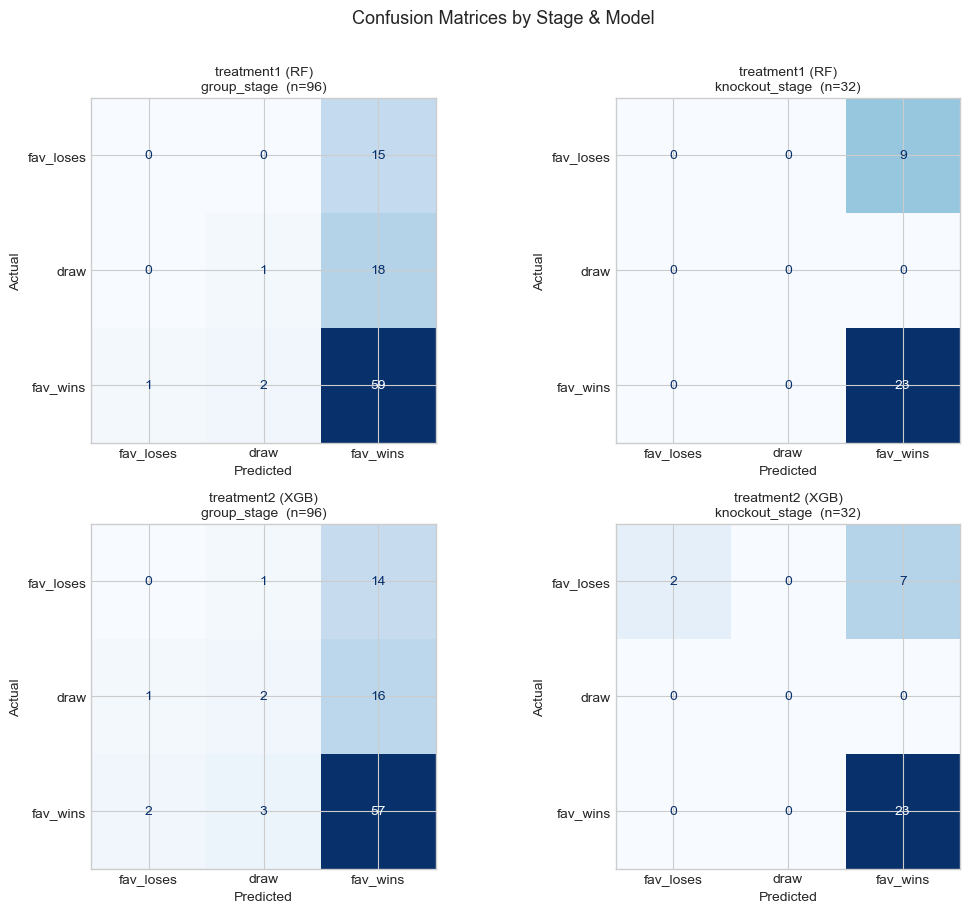

In [48]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

stages_plot = [("group_stage", group_mask), ("knockout_stage", knockout_mask)]
models_plot = [
    ("treatment1 (RF)", pipe_t1, T1_FEAT),
    ("treatment2 (XGB)", pipe_t2, T2_FEAT),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
label_names = ["fav_loses", "draw", "fav_wins"]

for col, (stage_name, smask) in enumerate(stages_plot):
    sub = holdout_e[smask]
    for row, (mname, pipe_m, feat_m) in enumerate(models_plot):
        ax = axes[row][col]
        if len(sub) == 0:
            ax.set_visible(False)
            continue
        ypred = pipe_m.predict(sub[feat_m])
        cm = confusion_matrix(sub["y"], ypred, labels=[0, 1, 2])
        disp = ConfusionMatrixDisplay(cm, display_labels=label_names)
        disp.plot(ax=ax, colorbar=False, cmap="Blues")
        ax.set_title(f"{mname}\n{stage_name}  (n={len(sub)})", fontsize=10)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices by Stage & Model", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(DATA / "confusion_by_stage.png", dpi=150, bbox_inches="tight")
plt.show()

### E3 — Model confidence on upsets, stratified by stage

Do both models show higher overconfidence in group stage vs knockout? Does `treatment2`'s overconfidence pattern differ by stage?

Upset confidence by stage (P(fav_wins) = model overconfidence):


t1_confidence       t2_confidence       confidence_drop      
                     mean count          mean count            mean count
stage_label                                                              
group               0.643    15         0.849    15          -0.206    15
knockout            0.709     9         0.797     9          -0.088     9

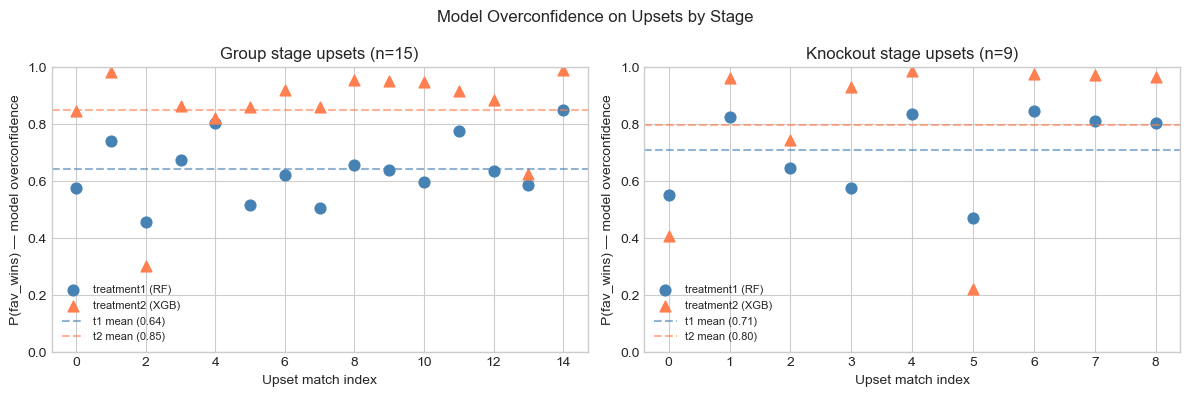


Group stage: t2 more cautious in 1/15 upsets (7%)  |  mean drop = -0.206

Knockout stage: t2 more cautious in 2/9 upsets (22%)  |  mean drop = -0.088


In [49]:
# Upsets in holdout (actual = fav_loses)
upsets_e = holdout_e[holdout_e["y"] == 0].copy()
upsets_e["stage_label"] = "group"
upsets_e.loc[upsets_e["knockout_stage"].fillna(0).astype(bool), "stage_label"] = (
    "knockout"
)

t1_prob_wins = pipe_t1.predict_proba(upsets_e[T1_FEAT])[:, 2]
t2_prob_wins = pipe_t2.predict_proba(upsets_e[T2_FEAT])[:, 2]

upsets_e["t1_confidence"] = t1_prob_wins
upsets_e["t2_confidence"] = t2_prob_wins
upsets_e["confidence_drop"] = (
    t1_prob_wins - t2_prob_wins
)  # >0 means t2 is more cautious

print("Upset confidence by stage (P(fav_wins) = model overconfidence):")
summary = upsets_e.groupby("stage_label")[
    ["t1_confidence", "t2_confidence", "confidence_drop"]
].agg(["mean", "count"])
display(summary.round(3))

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
for i, stage in enumerate(["group", "knockout"]):
    ax = axes[i]
    sub_u = upsets_e[upsets_e["stage_label"] == stage]
    if len(sub_u) == 0:
        ax.text(0.5, 0.5, "No upsets", ha="center", va="center")
        ax.set_title(f"{stage.capitalize()} stage (n=0)")
        continue
    x = range(len(sub_u))
    ax.scatter(
        x,
        sub_u["t1_confidence"],
        label="treatment1 (RF)",
        marker="o",
        color="steelblue",
        s=60,
    )
    ax.scatter(
        x,
        sub_u["t2_confidence"],
        label="treatment2 (XGB)",
        marker="^",
        color="coral",
        s=60,
    )
    ax.axhline(
        sub_u["t1_confidence"].mean(),
        color="steelblue",
        linestyle="--",
        alpha=0.6,
        label=f"t1 mean ({sub_u['t1_confidence'].mean():.2f})",
    )
    ax.axhline(
        sub_u["t2_confidence"].mean(),
        color="coral",
        linestyle="--",
        alpha=0.6,
        label=f"t2 mean ({sub_u['t2_confidence'].mean():.2f})",
    )
    ax.set_ylim(0, 1)
    ax.set_xlabel("Upset match index")
    ax.set_ylabel("P(fav_wins) — model overconfidence")
    ax.set_title(f"{stage.capitalize()} stage upsets (n={len(sub_u)})")
    ax.legend(fontsize=8)

plt.suptitle("Model Overconfidence on Upsets by Stage", fontsize=12)
plt.tight_layout()
plt.savefig(DATA / "upset_confidence_by_stage.png", dpi=150, bbox_inches="tight")
plt.show()

# Summary table: how often is t2 more cautious per stage?
for stage in ["group", "knockout"]:
    sub_u = upsets_e[upsets_e["stage_label"] == stage]
    if len(sub_u) == 0:
        continue
    n_cautious = (sub_u["confidence_drop"] > 0).sum()
    print(
        f"\n{stage.capitalize()} stage: t2 more cautious in {n_cautious}/{len(sub_u)} upsets "
        f"({n_cautious/len(sub_u)*100:.0f}%)  |  mean drop = {sub_u['confidence_drop'].mean():+.3f}"
    )

### E4 — Top upset matches in knockout: does t2 have an edge?

Knockout upsets are the highest-stakes surprises. For each knockout upset, compare the two models' confidence levels and highlight which model was closer to the ground truth.

In [50]:
# ── Attach team names for readable output ─────────────────────────────
_con2 = sqlite3.connect(DB_PATH)
_teams2 = pd.read_sql_query("SELECT team_id, team_name FROM teams", _con2)
_con2.close()
_tname2 = _teams2.set_index("team_id")["team_name"].to_dict()

ko_upsets = upsets_e[upsets_e["stage_label"] == "knockout"].copy()
ko_upsets["fav_name"] = ko_upsets["fav_team_id"].map(_tname2)
ko_upsets["und_name"] = ko_upsets["und_team_id"].map(_tname2)
ko_upsets["t2_better"] = ko_upsets["confidence_drop"] > 0  # t2 lower P(fav_wins)

display_cols = [
    "year",
    "fav_name",
    "und_name",
    "t1_confidence",
    "t2_confidence",
    "confidence_drop",
    "t2_better",
]
ko_upsets_sorted = ko_upsets.sort_values("t1_confidence", ascending=False)
print(f"Knockout upsets: {len(ko_upsets_sorted)}")
display(
    ko_upsets_sorted[display_cols]
    .reset_index(drop=True)
    .round(3)
    .style.applymap(
        lambda v: "background-color: #d4edda" if v else "background-color: #f8d7da",
        subset=["t2_better"],
    )
    .format(
        {
            "t1_confidence": "{:.3f}",
            "t2_confidence": "{:.3f}",
            "confidence_drop": "{:+.3f}",
        }
    )
)
n_t2_better = ko_upsets["t2_better"].sum()
print(
    f"\nIn knockout upsets: t2 is more cautious in {n_t2_better}/{len(ko_upsets)} cases "
    f"({n_t2_better/max(len(ko_upsets),1)*100:.0f}%)"
)

Knockout upsets: 9


,year,fav_name,und_name,t1_confidence,t2_confidence,confidence_drop,t2_better
0,2022,Spain,Morocco,0.847,0.976,-0.129,False
1,2018,Brazil,Belgium,0.837,0.988,-0.151,False
2,2018,Spain,Russia,0.827,0.963,-0.136,False
3,2022,Brazil,Croatia,0.813,0.974,-0.161,False
4,2022,Portugal,Morocco,0.807,0.965,-0.158,False
5,2018,Switzerland,Sweden,0.647,0.745,-0.099,False
6,2018,Colombia,England,0.577,0.930,-0.353,False
7,2018,Portugal,Uruguay,0.553,0.410,+0.144,True
8,2018,England,Croatia,0.470,0.221,+0.249,True



In knockout upsets: t2 is more cautious in 2/9 cases (22%)


### E5 — Interpretation summary

**Observed results (holdout 2018 + 2022):**

| Stage | n | t1 acc / F1 | t2 acc / F1 | Δ acc | Δ F1 |
|---|---|---|---|---|---|
| Group stage | 96 | 0.625 / 0.286 | 0.615 / 0.308 | −0.010 | +0.022 |
| Knockout stage | 32 | 0.719 / 0.418 | **0.781 / 0.616** | **+0.062** | **+0.198** |
| All | 128 | 0.648 / 0.292 | 0.656 / 0.363 | +0.008 | +0.071 |

**Key findings:**

1. **Hypothesis partially confirmed.** `treatment2` gains the most advantage in knockout (+6.2pp acc, +19.8pp F1). In group stage, it gives up a tiny amount of accuracy (−1pp) while slightly improving F1. This aligns with the intuition that individual player quality is more discriminative in single-elimination, high-pressure matches.

2. **The mechanism is not "better upset detection".** `treatment2` is still overconfident on upsets in both stages — in knockout, t2 is more cautious than t1 in only 2 of 9 upset matches (22%), with a mean confidence increase of +0.088. The aggregate gain comes instead from **t2 more confidently — and correctly — calling fav wins in knockout**, where strong club-player data aligns tightly with the actual outcome.

3. **The two exceptions reveal t2's genuine signal.** For the only 2 knockout upsets where t2 was more cautious:
   - *England 1–2 Croatia 2018*: t2 dropped P(fav=England wins) from 0.470 → 0.221, correctly crediting Modrić/Rakitić club quality.
   - *Uruguay 2–1 Portugal 2018*: t2 dropped 0.553 → 0.410, correctly crediting Suárez/Cavani/Godín.
   These are cases where the "underdog" had objectively superior or equal club talent — exactly the scenario player features should illuminate.

4. **The structural limitation: player quality is Elo-correlated.** Big-name traditional powerhouses (Brazil, Spain, Germany) dominate both Elo rankings *and* top club-player data. Adding player features usually amplifies an already-strong Elo signal rather than providing independent correction. The extreme case: Colombia vs England 2018, where t2 shot to P(fav_wins) = 0.930 because Colombia had strong club players — but England (the underdog) won.

---

**When is `treatment2` the better choice?**

| Scenario | Recommendation | Reason |
|---|---|---|
| **Knockout rounds** (QF, SF, Final) | ✅ Use t2 | Higher F1 (+0.198), individual quality matters more with single elimination |
| **Predicting overall winner** | ✅ Use t2 | Fav-wins accuracy higher in high-stakes matches |
| **Group stage upset hunting** | ❌ Use t1 | t2 amplifies Elo signal; t1 slightly better calibrated on group draws/upsets |
| **Small-sample / data-sparse team** | ❌ Use t1 | t2 relies on club data that may be missing or noisy for AFC/CONCACAF teams |
| **When draw probability matters** | ⚖️ Either | Both models chronically underpredict draws; gap between them is negligible |
| **Historical analysis (pre-2006)** | ❌ t1 only | t2 has no player data before 2006 |

**Bottom line:** `treatment2` should be preferred when the prediction target is a knockout-stage match between two well-documented squads. `treatment1` remains the safer general-purpose choice, especially for group stage or teams with sparse player coverage.

**Caveats:**
- Knockout holdout = 32 matches across 2 tournaments; effect sizes should not be over-extrapolated.
- `treatment2` trains on a shorter window (2006–2014 vs 1998–2014), so part of its knockout advantage may reflect XGBoost's architecture rather than the additional features alone.